## Regressão linear é possível com nossos dados?

In [1]:
from scipy import stats
from scipy.stats import shapiro, normaltest
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

def get_residuos(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    residuos = y_test - y_pred
    return y_pred, residuos

In [ ]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train_reg)

resultado_lr = avaliar_regressao("Regressão Linear (baseline)", modelo_lr, X_test, y_test_reg)

y_pred_lr, residuos_lr = get_residuos(modelo_lr, X_test, y_test_reg)

--- Regressão Linear (baseline) ---
RMSE: 0.3096
MAE:  0.1937
R²:   0.3112


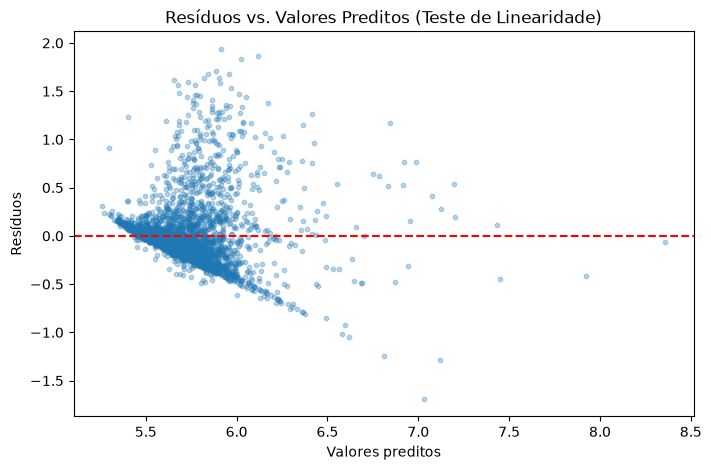

Interpretação:
- Se houver um padrão claro (curva, funil, etc.) em vez de uma nuvem aleatória,
  isso indica que a relação não é puramente linear ou há heterocedasticidade.


In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_lr, residuos_lr, alpha=0.3, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores preditos")
plt.ylabel("Resíduos")
plt.title("Resíduos vs. Valores Preditos (Teste de Linearidade)")
plt.show()

print("Interpretação:")
print("- Se houver um padrão claro (curva, funil, etc.) em vez de uma nuvem aleatória,")
print("  isso indica que a relação não é puramente linear ou há heterocedasticidade.")

In [ ]:
X_test_const = add_constant(X_test)
bp_test = het_breuschpagan(residuos_lr, X_test_const)

labels = ['LM Statistic', 'LM p-value', 'F-Statistic', 'F p-value']
print("--- Teste de Breusch-Pagan (Homocedasticidade) ---")
for label, val in zip(labels, bp_test):
    print(f"{label}: {val:.6f}")

print("\nH0: a variância dos resíduos é constante (homocedasticidade)")
if bp_test[1] < 0.05:
    print("p-valor < 0.05 -> rejeitamos H0: há evidência de HETEROCEDASTICIDADE")
else:
    print("p-valor >= 0.05 -> não rejeitamos H0: sem evidência forte de heterocedasticidade")

--- Teste de Breusch-Pagan (Homocedasticidade) ---
LM Statistic: 678.038251
LM p-value: 0.000000
F-Statistic: 4.217629
F p-value: 0.000000

H0: a variância dos resíduos é constante (homocedasticidade)
p-valor < 0.05 -> rejeitamos H0: há evidência de HETEROCEDASTICIDADE


--- Teste de D'Agostino-Pearson (Normalidade dos resíduos) ---
Estatística: 1721.5386, p-valor: 0.000000
p-valor < 0.05 -> resíduos provavelmente NÃO seguem distribuição normal


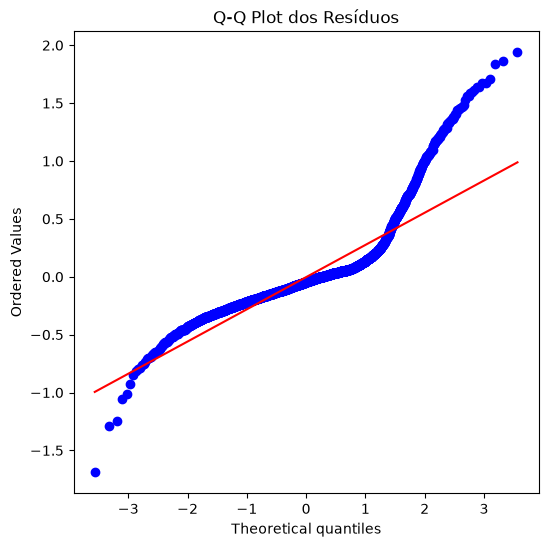

In [ ]:
# Shapiro-Wilk é sensível a amostras grandes; para datasets grandes, D'Agostino-Pearson é mais robusto
amostra_residuos = residuos_lr.sample(min(5000, len(residuos_lr)), random_state=RANDOM_STATE) \
    if hasattr(residuos_lr, 'sample') else residuos_lr

stat_dagostino, p_dagostino = normaltest(residuos_lr)
print("--- Teste de D'Agostino-Pearson (Normalidade dos resíduos) ---")
print(f"Estatística: {stat_dagostino:.4f}, p-valor: {p_dagostino:.6f}")

if p_dagostino < 0.05:
    print("p-valor < 0.05 -> resíduos provavelmente NÃO seguem distribuição normal")
else:
    print("p-valor >= 0.05 -> sem evidência forte contra normalidade")

# Q-Q plot
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(residuos_lr, dist="norm", plot=ax)
ax.set_title("Q-Q Plot dos Resíduos")
plt.show()

In [ ]:
dw_stat = durbin_watson(residuos_lr)
print(f"--- Estatística de Durbin-Watson: {dw_stat:.4f} ---")
print("Interpretação: valores próximos de 2 indicam ausência de autocorrelação.")
print("Valores < 1.5 ou > 2.5 sugerem autocorrelação positiva/negativa nos resíduos.")
print("(Relevante principalmente se há ordenação/estrutura sequencial nos dados;")
print(" no seu caso, jogos não têm ordem temporal natural, então isso é mais um diagnóstico secundário)")

--- Estatística de Durbin-Watson: 2.0323 ---
Interpretação: valores próximos de 2 indicam ausência de autocorrelação.
Valores < 1.5 ou > 2.5 sugerem autocorrelação positiva/negativa nos resíduos.
(Relevante principalmente se há ordenação/estrutura sequencial nos dados;
 no seu caso, jogos não têm ordem temporal natural, então isso é mais um diagnóstico secundário)


In [ ]:
# VIF pode ser custoso com 200 features; vamos calcular em lotes ou usar uma amostra de colunas
# Aviso: com muitas features, isso pode levar tempo. Ajuste conforme necessário.

def calcular_vif(X, max_features=None):
    X_amostra = X if max_features is None else X.iloc[:, :max_features]
    X_const = add_constant(X_amostra)
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) 
                        for i in range(X_const.shape[1])]
    return vif_data.sort_values("VIF", ascending=False)

# Comece com um subconjunto pequeno para não travar (ex: 30 primeiras features)
vif_resultado = calcular_vif(X_train, max_features=30)
print(vif_resultado.head(15))

print("\nInterpretação: VIF > 10 geralmente indica multicolinearidade severa.")
print("VIF > 5 já é motivo de atenção.")

c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


              feature        VIF
11         cat_Action        inf
21      cat_Dexterity        inf
0               const  26.652015
6            max_time   1.497709
5            min_time   1.495983
12      cat_Adventure   1.482930
27        cat_Fantasy   1.455885
2          complexity   1.432776
26    cat_Exploration   1.334216
1   min_suggested_age   1.306685
28       cat_Fighting   1.295833
16      cat_Card Game   1.281440
14        cat_Animals   1.272024
15       cat_Bluffing   1.192287
25  cat_Environmental   1.169633

Interpretação: VIF > 10 geralmente indica multicolinearidade severa.
VIF > 5 já é motivo de atenção.


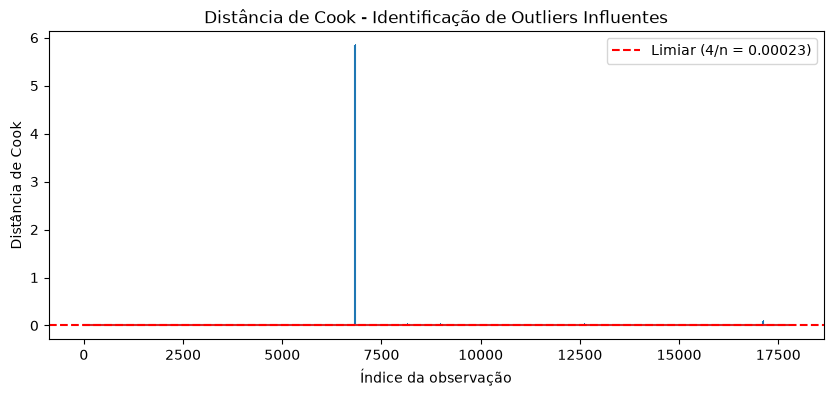

Número de observações potencialmente influentes (Cook's D > 4/n): 1319
Isso representa 7.43% do conjunto de treino


In [ ]:
# Usando statsmodels para calcular distância de Cook (mais direto que sklearn)
X_train_const = sm.add_constant(X_train)
modelo_sm = sm.OLS(y_train_reg, X_train_const).fit()

influence = modelo_sm.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(10, 4))
plt.stem(range(len(cooks_d)), cooks_d, markerfmt=",")
plt.xlabel("Índice da observação")
plt.ylabel("Distância de Cook")
plt.title("Distância de Cook - Identificação de Outliers Influentes")
plt.axhline(4/len(cooks_d), color='red', linestyle='--', label=f"Limiar (4/n = {4/len(cooks_d):.5f})")
plt.legend()
plt.show()

n_influentes = (cooks_d > 4/len(cooks_d)).sum()
print(f"Número de observações potencialmente influentes (Cook's D > 4/n): {n_influentes}")
print(f"Isso representa {100*n_influentes/len(cooks_d):.2f}% do conjunto de treino")

In [ ]:
# Comparar erro do modelo linear em diferentes faixas do target
faixas = pd.cut(y_test_reg, bins=[5, 5.6, 6.0, 7.0, 8.5], 
                 labels=['baixo (5-5.6)', 'médio (5.6-6.0)', 'alto (6.0-7.0)', 'muito alto (7.0-8.5)'])

df_erro = pd.DataFrame({
    'faixa': faixas,
    'erro_abs': np.abs(residuos_lr)
})

erro_por_faixa = df_erro.groupby('faixa')['erro_abs'].agg(['mean', 'count'])
print("--- Erro absoluto médio por faixa de geek_rating ---")
print(erro_por_faixa)

print("\nInterpretação: se o erro crescer muito nas faixas altas (cauda),")
print("o modelo linear está com dificuldade de capturar os jogos de rating elevado,")
print("que são justamente os outliers/influentes identificados no teste de Cook.")

--- Erro absoluto médio por faixa de geek_rating ---
                          mean  count
faixa                                
baixo (5-5.6)         0.135798   2459
médio (5.6-6.0)       0.133830    870
alto (6.0-7.0)        0.479999    388
muito alto (7.0-8.5)  1.132500     89

Interpretação: se o erro crescer muito nas faixas altas (cauda),
o modelo linear está com dificuldade de capturar os jogos de rating elevado,
que são justamente os outliers/influentes identificados no teste de Cook.


In [ ]:
# Verificar se há combinação linear exata entre as colunas problemáticas
# Provável causa: dummy trap ou correlação perfeita entre categorias

corr_check = X_train[['cat_Action', 'cat_Dexterity']].corrwith(X_train.drop(columns=['cat_Action', 'cat_Dexterity']))
print(corr_check.sort_values(key=abs, ascending=False).head(10))

# Também verifique se a soma de todas as dummies 'cat_' é constante (sinal de dummy trap)
cat_cols = [c for c in X_train.columns if c.startswith('cat_')]
soma_cats = X_train[cat_cols].sum(axis=1)
print("\nDistribuição da soma de todas as colunas cat_ por linha:")
print(soma_cats.value_counts().head())

cat_Abstract Strategy   NaN
cat_Action              NaN
cat_Adventure           NaN
cat_Ancient             NaN
cat_Animals             NaN
cat_Bluffing            NaN
cat_Card Game           NaN
cat_Children's Game     NaN
cat_City Building       NaN
cat_Civilization        NaN
dtype: float64

Distribuição da soma de todas as colunas cat_ por linha:
0    15971
2      505
1      449
3      351
4      248
Name: count, dtype: int64
